SWATHI-24BAD122 IMPLEMENTATION OF RNN FOR TEXT GENERATION

In [2]:
# ============================================================
# EXPERIMENT NO: 5
# IMPLEMENTATION OF RNN FOR TEXT GENERATION
# TASK A: DATASET PREPARATION
# ROLL NO: 24BAD122
# DATE: 15/09/2026
# ============================================================

# ------------------------------------------------------------
# STEP 1: INSTALL AND IMPORT LIBRARIES
# ------------------------------------------------------------

!pip install -q datasets

import numpy as np
import tensorflow as tf
from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Random seed
np.random.seed(42)
tf.random.set_seed(42)

print("=" * 60)
print("TASK A - DATASET PREPARATION")
print("ROLL NO: 24BAD122")
print("=" * 60)


# ------------------------------------------------------------
# STEP 2: LOAD TINY SHAKESPEARE DATASET
# ------------------------------------------------------------

print("\n1. LOADING DATASET")
print("-" * 60)

dataset = load_dataset("Trelis/tiny-shakespeare")

print(dataset)


# ------------------------------------------------------------
# STEP 3: FIND TEXT COLUMN
# ------------------------------------------------------------

print("\n2. DATASET EXPLORATION")
print("-" * 60)

print("Dataset type:", type(dataset))

# Display available columns
print("Available columns:",
      dataset["train"].column_names)

# Automatically find the text column
if "Text" in dataset["train"].column_names:
    text_column = "Text"
elif "text" in dataset["train"].column_names:
    text_column = "text"
else:
    raise ValueError("Text column not found.")

print("Text column selected:", text_column)


# ------------------------------------------------------------
# STEP 4: EXTRACT TEXT
# ------------------------------------------------------------

text = dataset["train"][0][text_column]

print("\nText data type:", type(text))
print("Total number of characters:", len(text))

print("\nFirst 500 characters:")
print("-" * 60)
print(text[:500])
print("-" * 60)


# ------------------------------------------------------------
# STEP 5: CONVERT TEXT TO LOWERCASE
# ------------------------------------------------------------

print("\n3. CONVERTING TEXT TO LOWERCASE")
print("-" * 60)

text = text.lower()

print("First 500 characters after lowercase conversion:")
print("-" * 60)
print(text[:500])
print("-" * 60)


# ------------------------------------------------------------
# STEP 6: TOKENIZATION
# ------------------------------------------------------------

print("\n4. TOKENIZATION")
print("-" * 60)

tokenizer = Tokenizer(
    oov_token="<OOV>"
)

# Build vocabulary
tokenizer.fit_on_texts([text])

# Convert text into integer IDs
tokens = tokenizer.texts_to_sequences([text])[0]

# Display first 30 words
words = text.split()

print("First 30 words:")
print(words[:30])

print("\nFirst 30 token IDs:")
print(tokens[:30])


# ------------------------------------------------------------
# STEP 7: BUILD VOCABULARY
# ------------------------------------------------------------

print("\n5. BUILDING VOCABULARY")
print("-" * 60)

word_index = tokenizer.word_index

# +1 for padding index 0
vocab_size = len(word_index) + 1

print("Vocabulary size:", vocab_size)

print("\nFirst 20 words and their integer IDs:")
print("-" * 40)

for word, index in list(word_index.items())[:20]:
    print(f"{word:15s} : {index}")


# ------------------------------------------------------------
# STEP 8: GENERATE INPUT SEQUENCES
# ------------------------------------------------------------

print("\n6. GENERATING INPUT SEQUENCES")
print("-" * 60)

# Number of previous words
sequence_length = 10

input_sequences = []

for i in range(sequence_length, len(tokens)):

    # 10 input words + 1 target word
    sequence = tokens[i-sequence_length:i+1]

    input_sequences.append(sequence)

input_sequences = np.array(input_sequences)

print("Total sequences generated:",
      len(input_sequences))

print("\nExample complete sequence:")
print(input_sequences[0])


# ------------------------------------------------------------
# STEP 9: SEPARATE INPUT AND TARGET
# ------------------------------------------------------------

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("\nInput X shape:", X.shape)
print("Target y shape:", y.shape)

print("\nFirst input sequence:")
print(X[0])

print("\nFirst target word ID:")
print(y[0])


# ------------------------------------------------------------
# STEP 10: DISPLAY INPUT WORDS AND TARGET WORD
# ------------------------------------------------------------

print("\nNEXT-WORD PREDICTION EXAMPLE")
print("-" * 60)

first_input_words = []

for token_id in X[0]:

    word = tokenizer.index_word.get(
        token_id,
        "<UNKNOWN>"
    )

    first_input_words.append(word)

target_word = tokenizer.index_word.get(
    y[0],
    "<UNKNOWN>"
)

print("Input words :", " ".join(first_input_words))
print("Target word :", target_word)


# ------------------------------------------------------------
# STEP 11: APPLY SEQUENCE PADDING
# ------------------------------------------------------------

print("\n7. APPLYING SEQUENCE PADDING")
print("-" * 60)

X = pad_sequences(
    X,
    maxlen=sequence_length,
    padding="pre"
)

print("After padding:")
print("X shape:", X.shape)

print("\nFirst padded sequence:")
print(X[0])


# ------------------------------------------------------------
# STEP 12: TRAINING AND VALIDATION SPLIT
# ------------------------------------------------------------

print("\n8. TRAINING AND VALIDATION SPLIT")
print("-" * 60)

# 80% training and 20% validation
split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]

X_val = X[split:]
y_val = y[split:]


# ------------------------------------------------------------
# STEP 13: DISPLAY FINAL DATASET SHAPES
# ------------------------------------------------------------

print("\nFINAL DATASET SHAPES")
print("=" * 60)

print("X_train shape :", X_train.shape)
print("y_train shape :", y_train.shape)

print("X_val shape   :", X_val.shape)
print("y_val shape   :", y_val.shape)


# ------------------------------------------------------------
# STEP 14: FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TASK A COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Dataset            : Tiny Shakespeare")
print("Roll Number        : 24BAD122")
print("Text Column        :", text_column)
print("Vocabulary Size    :", vocab_size)
print("Sequence Length    :", sequence_length)
print("Total Sequences    :", len(X))

print("Training Samples   :", len(X_train))
print("Validation Samples :", len(X_val))

print("Training Split     : 80%")
print("Validation Split   : 20%")

print("\nTASK A STEPS COMPLETED:")
print("✓ Dataset loaded from Hugging Face")
print("✓ Dataset explored")
print("✓ Text converted to lowercase")
print("✓ Text tokenized")
print("✓ Vocabulary created")
print("✓ Integer IDs assigned")
print("✓ Input sequences generated")
print("✓ Sequence padding applied")
print("✓ Training dataset created")
print("✓ Validation dataset created")

print("=" * 60)

TASK A - DATASET PREPARATION
ROLL NO: 24BAD122

1. LOADING DATASET
------------------------------------------------------------
DatasetDict({
    train: Dataset({
        features: ['Text'],
        num_rows: 472
    })
    test: Dataset({
        features: ['Text'],
        num_rows: 49
    })
})

2. DATASET EXPLORATION
------------------------------------------------------------
Dataset type: <class 'datasets.dataset_dict.DatasetDict'>
Available columns: ['Text']
Text column selected: Text

Text data type: <class 'str'>
Total number of characters: 3131

First 500 characters:
------------------------------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a

In [3]:
# ============================================================
# EXPERIMENT NO: 5
# IMPLEMENTATION OF RNN FOR TEXT GENERATION
# TASK B: IMPLEMENTING THE RNN MODEL
# ROLL NO: 24BAD122
# DATE: 15/09/2026
# ============================================================

import tensorflow as tf

print("=" * 60)
print("TASK B - IMPLEMENTING THE RNN MODEL")
print("ROLL NO: 24BAD122")
print("=" * 60)


# ------------------------------------------------------------
# STEP 1: DEFINE MODEL PARAMETERS
# ------------------------------------------------------------

embedding_dim = 64
rnn_units = 128

print("\nMODEL PARAMETERS")
print("-" * 60)

print("Vocabulary Size :", vocab_size)
print("Sequence Length :", sequence_length)
print("Embedding Dimension :", embedding_dim)
print("RNN Units :", rnn_units)


# ------------------------------------------------------------
# STEP 2: CREATE RNN MODEL
# ------------------------------------------------------------

model = tf.keras.Sequential([

    # Embedding Layer
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),

    # Simple RNN Layer
    tf.keras.layers.SimpleRNN(
        rnn_units
    ),

    # Dense Output Layer with Softmax
    tf.keras.layers.Dense(
        vocab_size,
        activation="softmax"
    )
])


# ------------------------------------------------------------
# STEP 3: BUILD THE MODEL
# ------------------------------------------------------------

model.build(
    input_shape=(None, sequence_length)
)


# ------------------------------------------------------------
# STEP 4: DISPLAY MODEL ARCHITECTURE
# ------------------------------------------------------------

print("\nMODEL ARCHITECTURE")
print("=" * 60)

model.summary()


# ------------------------------------------------------------
# STEP 5: COMPILE THE MODEL
# ------------------------------------------------------------

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# STEP 6: DISPLAY COMPILE INFORMATION
# ------------------------------------------------------------

print("\nMODEL COMPILATION")
print("=" * 60)

print("Optimizer : Adam")
print("Loss Function : Sparse Categorical Crossentropy")
print("Evaluation Metric : Accuracy")


# ------------------------------------------------------------
# STEP 7: DISPLAY LAYER INFORMATION
# ------------------------------------------------------------

print("\nLAYER INFORMATION")
print("=" * 60)

print("1. Embedding Layer")
print("   Converts word IDs into dense vector representations.")

print("\n2. Simple RNN Layer")
print("   Learns sequential dependencies from previous words.")

print("\n3. Dense + Softmax Layer")
print("   Predicts the probability of every word in the vocabulary.")


# ------------------------------------------------------------
# STEP 8: MODEL ARCHITECTURE FLOW
# ------------------------------------------------------------

print("\nMODEL FLOW")
print("=" * 60)

print("Input Sequence")
print("      ↓")
print("Embedding Layer")
print("      ↓")
print("Simple RNN Layer")
print("      ↓")
print("Dense Layer")
print("      ↓")
print("Softmax")
print("      ↓")
print("Next Word Prediction")


# ------------------------------------------------------------
# TASK B COMPLETED
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TASK B COMPLETED SUCCESSFULLY")
print("=" * 60)

print("✓ Embedding layer created")
print("✓ Simple RNN layer added")
print("✓ Dense layer added")
print("✓ Softmax activation applied")
print("✓ Adam optimizer selected")
print("✓ Sparse categorical crossentropy selected")
print("✓ Model compiled")
print("✓ Model summary displayed")

print("=" * 60)

TASK B - IMPLEMENTING THE RNN MODEL
ROLL NO: 24BAD122

MODEL PARAMETERS
------------------------------------------------------------
Vocabulary Size : 261
Sequence Length : 10
Embedding Dimension : 64
RNN Units : 128

MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 10, 64)         │        16,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 261)            │        33,669 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,077 (293.27 KB)

 Trainable params: 75,077 (293.27 KB)

 Non-trainable params: 0 (0.00 B)


MODEL COMPILATION
Optimizer : Adam
Loss Function : Sparse Categorical Crossentropy
Evaluation Metric : Accuracy

LAYER INFORMATION
1. Embedding Layer
   Converts word IDs into dense vector representations.

2. Simple RNN Layer
   Learns sequential dependencies from previous words.

3. Dense + Softmax Layer
   Predicts the probability of every word in the vocabulary.

MODEL FLOW
Input Sequence
      ↓
Embedding Layer
      ↓
Simple RNN Layer
      ↓
Dense Layer
      ↓
Softmax
      ↓
Next Word Prediction

TASK B COMPLETED SUCCESSFULLY
✓ Embedding layer created
✓ Simple RNN layer added
✓ Dense layer added
✓ Softmax activation applied
✓ Adam optimizer selected
✓ Sparse categorical crossentropy selected
✓ Model compiled
✓ Model summary displayed


TASK C - RNN MODEL TRAINING AND PERFORMANCE EVALUATION
ROLL NO: 24BAD122

TRAINING PARAMETERS
------------------------------------------------------------
Number of Epochs : 10
Batch Size       : 128
Optimizer        : Adam
Loss Function    : Sparse Categorical Crossentropy

STARTING MODEL TRAINING
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.0023 - loss: 5.5723 - val_accuracy: 0.0000e+00 - val_loss: 5.5656
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.0367 - loss: 5.4948 - val_accuracy: 0.0000e+00 - val_loss: 5.5635
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.1032 - loss: 5.4037 - val_accuracy: 0.0000e+00 - val_loss: 5.5675
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0688 - loss: 5.2480 - val_accuracy: 0.0275 - val_loss: 5.6574
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0459 - loss: 5.1216 - val_accuracy: 0.0183 - val_loss: 5.7381
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 

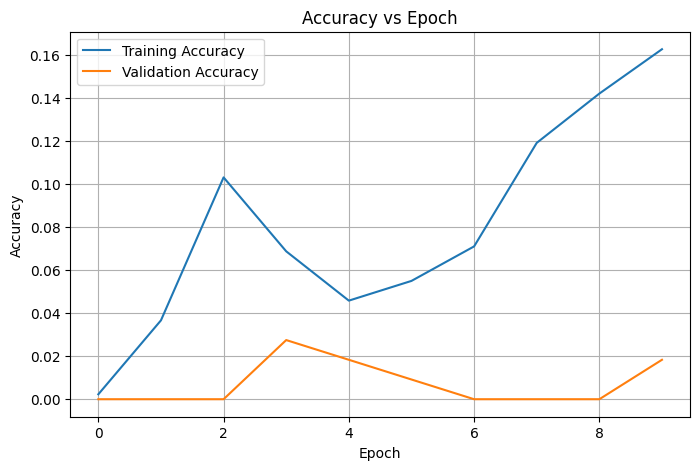

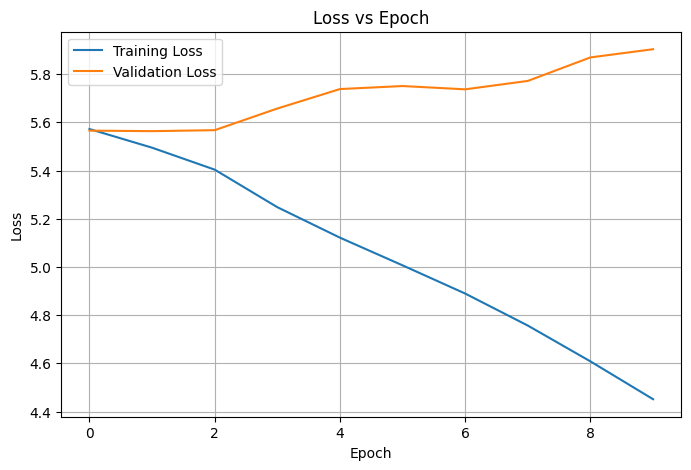


TASK C COMPLETED SUCCESSFULLY
✓ RNN model trained
✓ Training data used
✓ Validation data used
✓ Training accuracy recorded
✓ Validation accuracy recorded
✓ Training loss recorded
✓ Validation loss recorded
✓ Accuracy vs Epoch graph generated
✓ Loss vs Epoch graph generated


In [4]:
# ============================================================
# EXPERIMENT NO: 5
# IMPLEMENTATION OF RNN FOR TEXT GENERATION
# TASK C: RNN MODEL TRAINING AND PERFORMANCE EVALUATION
# ROLL NO: 24BAD122
# DATE: 15/09/2026
# ============================================================

import matplotlib.pyplot as plt

print("=" * 60)
print("TASK C - RNN MODEL TRAINING AND PERFORMANCE EVALUATION")
print("ROLL NO: 24BAD122")
print("=" * 60)


# ------------------------------------------------------------
# STEP 1: DEFINE TRAINING PARAMETERS
# ------------------------------------------------------------

epochs = 10
batch_size = 128

print("\nTRAINING PARAMETERS")
print("-" * 60)

print("Number of Epochs :", epochs)
print("Batch Size       :", batch_size)
print("Optimizer        : Adam")
print("Loss Function    : Sparse Categorical Crossentropy")


# ------------------------------------------------------------
# STEP 2: TRAIN THE RNN MODEL
# ------------------------------------------------------------

print("\nSTARTING MODEL TRAINING")
print("=" * 60)

history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    verbose=1
)


# ------------------------------------------------------------
# STEP 3: EVALUATE MODEL ON VALIDATION DATA
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

validation_loss, validation_accuracy = model.evaluate(
    X_val,
    y_val,
    verbose=0
)

print("Validation Loss     :", validation_loss)
print("Validation Accuracy :", validation_accuracy)


# ------------------------------------------------------------
# STEP 4: GET FINAL TRAINING RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL TRAINING RESULTS")
print("=" * 60)

training_accuracy = history.history["accuracy"][-1]
training_loss = history.history["loss"][-1]

validation_accuracy_history = history.history["val_accuracy"][-1]
validation_loss_history = history.history["val_loss"][-1]

print("Training Accuracy   :", training_accuracy)
print("Validation Accuracy :", validation_accuracy_history)

print("Training Loss       :", training_loss)
print("Validation Loss     :", validation_loss_history)


# ------------------------------------------------------------
# STEP 5: DISPLAY RESULTS FOR ALL EPOCHS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PERFORMANCE FOR EACH EPOCH")
print("=" * 60)

for i in range(epochs):

    print(
        f"Epoch {i+1:02d} | "
        f"Training Accuracy: {history.history['accuracy'][i]:.4f} | "
        f"Validation Accuracy: {history.history['val_accuracy'][i]:.4f} | "
        f"Training Loss: {history.history['loss'][i]:.4f} | "
        f"Validation Loss: {history.history['val_loss'][i]:.4f}"
    )


# ------------------------------------------------------------
# STEP 6: PLOT ACCURACY VS EPOCH
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# STEP 7: PLOT LOSS VS EPOCH
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# STEP 8: TASK C SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TASK C COMPLETED SUCCESSFULLY")
print("=" * 60)

print("✓ RNN model trained")
print("✓ Training data used")
print("✓ Validation data used")
print("✓ Training accuracy recorded")
print("✓ Validation accuracy recorded")
print("✓ Training loss recorded")
print("✓ Validation loss recorded")
print("✓ Accuracy vs Epoch graph generated")
print("✓ Loss vs Epoch graph generated")

print("=" * 60)

In [5]:
# ============================================================
# EXPERIMENT NO. 5
# TASK D – TEXT GENERATION USING RNN
# NAME: SWATHI
# ROLL NO: 24BAD122
# DATE: 15/09/2026
# ============================================================

import numpy as np

# ------------------------------------------------------------
# STEP 1: Function to generate text
# ------------------------------------------------------------

def generate_text(seed_text, num_words=20):

    generated_text = seed_text.lower()

    for _ in range(num_words):

        # Convert seed text into integer sequence
        token_list = tokenizer.texts_to_sequences([generated_text])[0]

        # Keep only the last sequence_length words
        token_list = token_list[-sequence_length:]

        # Apply padding
        token_list = tf.keras.preprocessing.sequence.pad_sequences(
            [token_list],
            maxlen=sequence_length,
            padding="pre"
        )

        # Predict next word
        predictions = model.predict(token_list, verbose=0)

        # Select word with highest probability
        predicted_id = np.argmax(predictions, axis=-1)[0]

        # Convert integer back to word
        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted_id:
                output_word = word
                break

        # Stop if no word is found
        if output_word == "":
            break

        # Add predicted word
        generated_text += " " + output_word

    return generated_text


# ------------------------------------------------------------
# STEP 2: Generate text using different seed sentences
# ------------------------------------------------------------

seed_inputs = [
    "the king",
    "i have",
    "lord",
    "what shall",
    "the world"
]

print("=" * 70)
print("RNN TEXT GENERATION RESULTS")
print("=" * 70)

results = []

for seed in seed_inputs:

    generated = generate_text(seed, num_words=20)

    print("\nSeed Input :", seed)
    print("Generated  :", generated)

    results.append((seed, generated))


# ------------------------------------------------------------
# STEP 3: Display comparison
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPARISON OF GENERATED TEXT")
print("=" * 70)

for i, (seed, generated) in enumerate(results, start=1):
    print(f"\n{i}. Seed      : {seed}")
    print(f"   Generated : {generated}")


# ------------------------------------------------------------
# STEP 4: Basic observations
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("OBSERVATIONS")
print("=" * 70)

print("""
1. The RNN predicts one word at a time based on the previous words.
2. Different seed inputs produce different generated sequences.
3. The generated text follows patterns learned from the training data.
4. Some sentences may be meaningful while others may be repetitive.
5. Better coherence can be obtained using more training data and epochs.
""")

RNN TEXT GENERATION RESULTS

Seed Input : the king
Generated  : the king first to first you to the first to the first citizen to first to to the to to first to

Seed Input : i have
Generated  : i have first first to you you to the first to the to to first you to to the to to first

Seed Input : lord
Generated  : lord first first first you to first first to the first to to to to first you to to first to

Seed Input : what shall
Generated  : what shall first first to you to you the you the the to to first you first to first to the the

Seed Input : the world
Generated  : the world first to first you to the first to the first citizen to first to to the to to first to

COMPARISON OF GENERATED TEXT

1. Seed      : the king
   Generated : the king first to first you to the first to the first citizen to first to to the to to first to

2. Seed      : i have
   Generated : i have first first to you you to the first to the to to first you to to the to to first

3. Seed      : lord
   Generated :